# Análisis Exploratorio de Datos (EDA)



In [1]:
import sys
import os
sys.path.append(os.path.abspath("../scripts"))

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import bases

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Cargar datos
print("Cargando datos principales...")
df_pacientes = bases.cargar_datos_pacientes("../data/pacientes.xlsx")
traslados = bases.reconstruir_traslados(df_pacientes)
print("Pacientes y traslados cargados.")


# Geografia
print("Cargando datos geográficos...")
hosp_coords = bases.cargar_coordenadas("../data/hospitales_coordenadas.csv")
municipios = bases.cargar_municipios("../data/shapefiles/departamento/departamentoPolygon.shp")
municipios_amba = municipios[
    municipios["in1"].astype(str).str.startswith(("0"))
]
amba_partidos_caso = [
    "QUILMES", "ALMIRANTE BROWN",
    "FLORENCIO VARELA", "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]
municipios_amba = municipios_amba[municipios_amba["nam_limpio"].isin(
    amba_partidos_caso)]

print("Datos geográficos cargados.")

Cargando datos principales...
Pacientes y traslados cargados.
Cargando datos geográficos...
Datos geográficos cargados.


In [ ]:
df_pacientes

## ACTUALIZAR EL DATASET

,Id Hospital,Nombre Hospital,Id,Fecha inicio,Estado al ingreso,Tipo al ingreso,Último estado,Último tipo,Sexo,Edad,Nivel riesgo clínico,Nivel riesgo social,Enfermedades preexistentes,Motivo,Operación,Fecha egreso,Última actualización,Duracion días,murio
0,1,EL CRUCE,Mariano,NaT,sospechosos,criticas,sospechosos,criticas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2020-07-21 17:34:40,NaN,False
1,1,EL CRUCE,12345,NaT,sospechosos,intermedias,sospechosos,criticas,NaN,40,grave,si,enfermedad-cardiovascular,NaN,NaN,NaT,2020-07-21 17:34:40,NaN,False
2,1,EL CRUCE,24698750,2020-05-10 18:07:34,sospechosos,criticas,sospechosos,criticas,femenino,44,intermedio,no,"hipertension, enfermedad-renal-cronica",NaN,NaN,NaT,2020-07-21 17:34:40,NaN,False
3,1,EL CRUCE,1001,2020-05-28 18:07:34,ocupadas_covid,intermedias,ocupadas_covid,intermedias,masculino,49,intermedio,no,"enfermedad-cardiovascular, enfermedad-renal-cr...",alta-domiciliaria,egreso,2020-06-09 18:07:34,2020-07-21 17:34:40,12.0,False
4,1,EL CRUCE,1002,2020-05-15 18:07:34,ocupadas_covid,criticas,ocupadas_covid,intermedias,femenino,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2020-07-21 17:34:40,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7395,148,UPA 10 - BE,LN39,NaT,sospechosos,intermedias,sospechosos,intermedias,NaN,NaN,NaN,NaN,NaN,alta-domiciliaria,egreso,NaT,2020-10-29 22:11:42,NaN,False
7396,148,UPA 10 - BE,RL37,NaT,sospechosos,intermedias,sospechosos,intermedias,NaN,NaN,NaN,NaN,NaN,alta-domiciliaria,egreso,NaT,2020-10-29 22:11:49,NaN,False
7397,148,UPA 10 - BE,ZL24,NaT,sospechosos,intermedias,sospechosos,intermedias,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2020-10-30 13:36:09,NaN,False
7398,148,UPA 10 - BE,RT93,NaT,sospechosos,intermedias,sospechosos,intermedias,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2020-10-30 13:36:12,NaN,False


In [22]:
(len(traslados)/len(df_pacientes))*100

6.703608595756183

## 1. Funcionamiento de la Red General (AMBA)

### 1.1 Mapa con los hospitales y sus municipios alrededor

Registros luego de filtros: 496
Hospitales origen únicos: 12
Hospitales destino únicos: 12
Nodos en red: 13
Aristas en red: 40
Ignorados (no encontrados en hosp_coords): {'MODULO HOSPITALARIO    AB'}


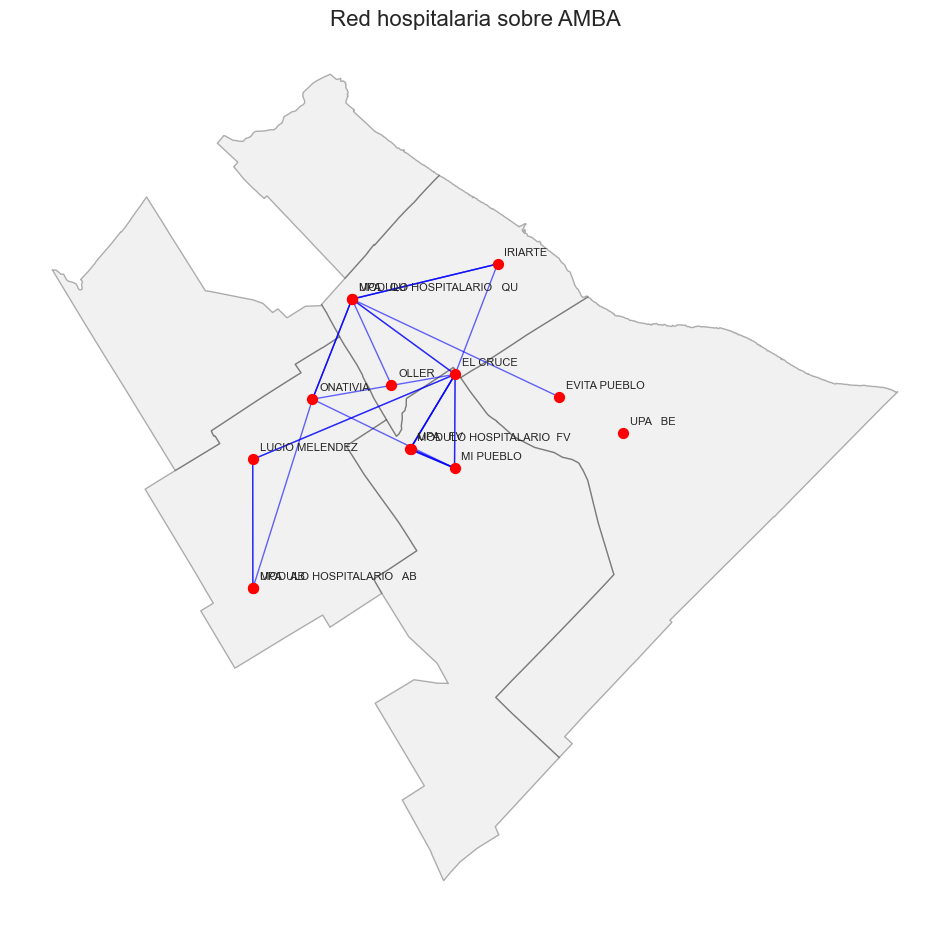

In [23]:
# Generar red
G, edges, fig_tuple = bases.analizar_red_hospitalaria(
    traslados, hosp_coords, 
    peso_minimo=1, 
    modo="estatico", 
    mostrar_resumen=True, 
    graficar=False
)

# Convertir red y nodos a GeoDataFrames
gdf_edges, gdf_nodes = bases.gdf_red_hospitalaria(G, hosp_coords)

# Graficar
bases.plot_red_sobre_amba(gdf_edges, gdf_nodes, municipios_amba, mostrar_nombres=True, mostrar_peso=False)

In [24]:
#### direccionar
#### cuurvadas
#### elegir sistema para los upas

### 1.2 Total de traslados

In [25]:
# Resumen de traslados
res_tras = bases.resumen_traslados(traslados, imprimir=True)

Total de traslados: 496
Cantidad de hospitales únicos: 12


### 1.3 Cantidad de traslados en función del tiempo

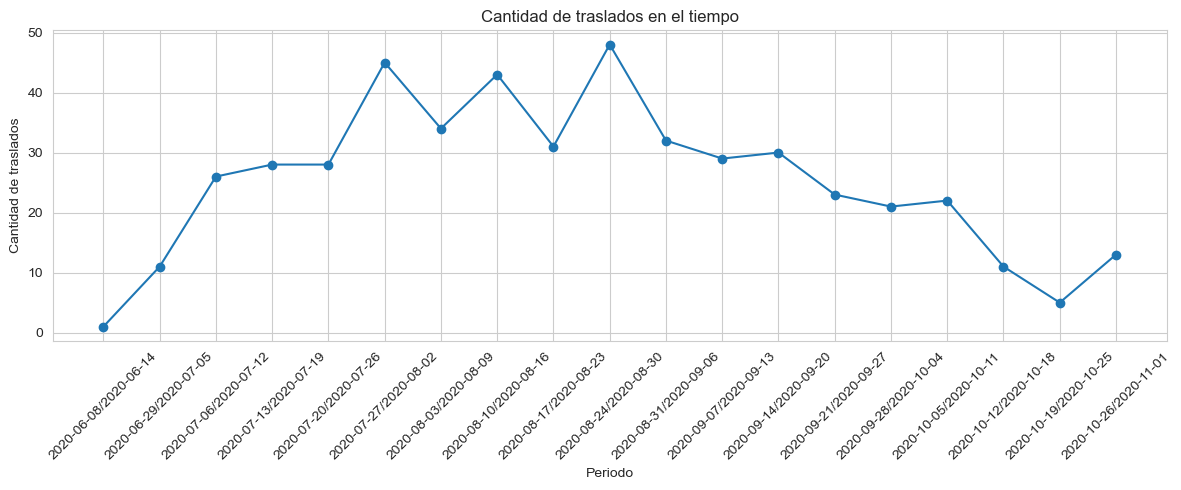

Fecha egreso
2020-06-08/2020-06-14     1
2020-06-29/2020-07-05    11
2020-07-06/2020-07-12    26
2020-07-13/2020-07-19    28
2020-07-20/2020-07-26    28
2020-07-27/2020-08-02    45
2020-08-03/2020-08-09    34
2020-08-10/2020-08-16    43
2020-08-17/2020-08-23    31
2020-08-24/2020-08-30    48
2020-08-31/2020-09-06    32
2020-09-07/2020-09-13    29
2020-09-14/2020-09-20    30
2020-09-21/2020-09-27    23
2020-09-28/2020-10-04    21
2020-10-05/2020-10-11    22
2020-10-12/2020-10-18    11
2020-10-19/2020-10-25     5
2020-10-26/2020-11-01    13
dtype: int64

In [26]:
bases.traslados_en_el_tiempo(traslados, freq="W")

### 1.4 Top de flujos entre hospitales (Caminos más frecuentes)

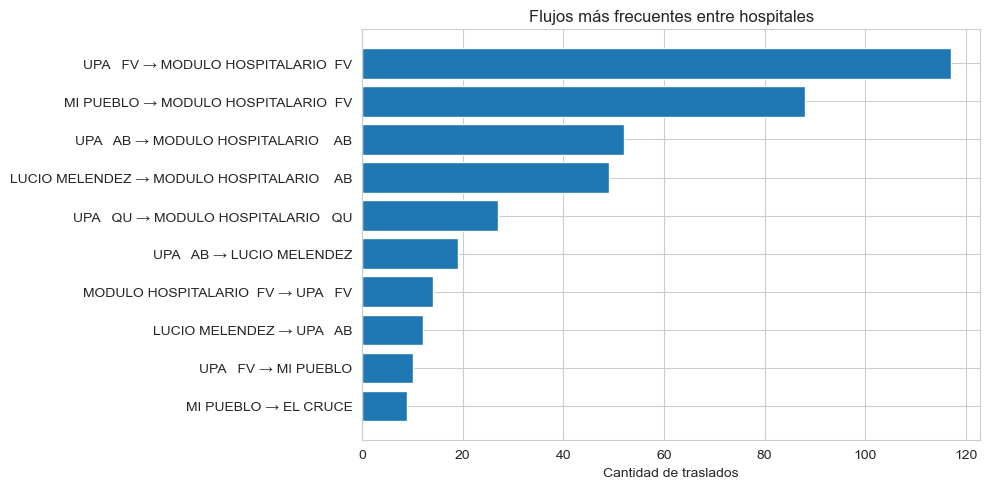

,Nombre Hospital,Hospital siguiente,cantidad
37,UPA FV,MODULO HOSPITALARIO FV,117
14,MI PUEBLO,MODULO HOSPITALARIO FV,88
34,UPA AB,MODULO HOSPITALARIO AB,52
11,LUCIO MELENDEZ,MODULO HOSPITALARIO AB,49
38,UPA QU,MODULO HOSPITALARIO QU,27
33,UPA AB,LUCIO MELENDEZ,19
26,MODULO HOSPITALARIO FV,UPA FV,14
12,LUCIO MELENDEZ,UPA AB,12
36,UPA FV,MI PUEBLO,10
13,MI PUEBLO,EL CRUCE,9


In [38]:
bases.top_flujos_hospitales(traslados, top_n=10)

### 1.5 Métricas de la red (Grafos)

In [28]:
bases.metricas_red(G, top_n=10)

Top hospitales por betweenness:
                     hospital  degree_centrality  betweenness  in_degree  \
0                    EL CRUCE           1.166667     0.477273         45   
4    MODULO HOSPITALARIO   QU           0.750000     0.333333         38   
11                   ONATIVIA           0.666667     0.250000          2   
9                    UPA   QU           0.416667     0.106061          5   
3   MODULO HOSPITALARIO    AB           0.666667     0.083333        110   
1              LUCIO MELENDEZ           0.500000     0.075758         24   
2                   MI PUEBLO           0.583333     0.064394         16   
5     MODULO HOSPITALARIO  FV           0.500000     0.000000        210   
6                    UPA   FV           0.500000     0.000000         23   
8                     IRIARTE           0.333333     0.000000          6   

    out_degree  
0           14  
4           13  
11          20  
9           28  
3           10  
1           63  
2          1

,hospital,degree_centrality,betweenness,in_degree,out_degree
0,EL CRUCE,1.166667,0.477273,45,14
4,MODULO HOSPITALARIO QU,0.750000,0.333333,38,13
11,ONATIVIA,0.666667,0.250000,2,20
9,UPA QU,0.416667,0.106061,5,28
3,MODULO HOSPITALARIO AB,0.666667,0.083333,110,10
1,LUCIO MELENDEZ,0.500000,0.075758,24,63
2,MI PUEBLO,0.583333,0.064394,16,101
5,MODULO HOSPITALARIO FV,0.500000,0.000000,210,26
6,UPA FV,0.500000,0.000000,23,133
8,IRIARTE,0.333333,0.000000,6,16


In [ ]:
### Quizas poner par a par
# pagerank

## 2. Trayectorias de Paciente

### 2.1 Cantidad de traslados para cada persona (promedio y desvío, junto a distribución)

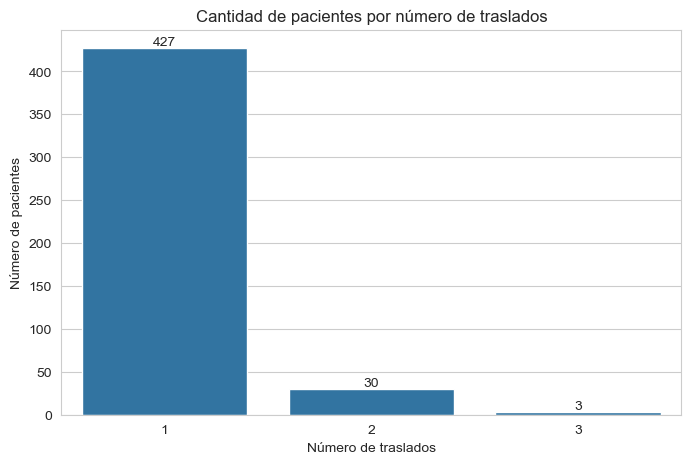

Promedio de traslados por paciente: 1.0782608695652174
Desvío estándar: 0.29217316878347405


In [29]:
# Distribución de traslados por paciente
conteo_tras_paciente, stats_tras_paciente = bases.distribucion_traslados_paciente(traslados, col_id="Id", valores=[1, 2, 3, 4, 5, 6, 7], graficar=True)

In [ ]:
## que paso con estos 3?
## reconstruir estos 3

# incluir los ingresos como porcentaje. escala logaritmica

# PROBABILIDAD DE TENER UN TRASLADO MAS DADO LA CANTIDAD DE TRASLADOS QUE TUVISTE

# Cuantos de esos tambien tienen como lo que tuviste

### 2.2 Tiempo dentro del sistema por persona

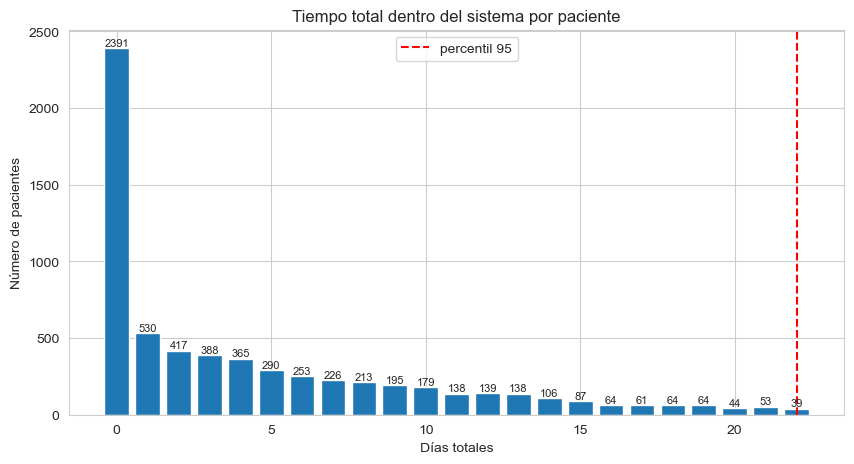

In [42]:
# Tiempo en el sistema por persona
tiempo_sis, limite_tiempo = bases.tiempo_total_paciente(df_pacientes, col_id="Id", col_dias="Duracion días", max_dias=100, quantile_outlier=0.95, graficar=True)

In [31]:
print("n pacientes:", len(tiempo_sis))
print("min:", tiempo_sis.min())
print("max:", tiempo_sis.max())
print("valores:", tiempo_sis.value_counts().head(10))

n pacientes: 6767
min: 0.0
max: 95.0
valores: Duracion días
0.0    2391
1.0     530
2.0     417
3.0     388
4.0     365
5.0     290
6.0     253
7.0     226
8.0     213
9.0     195
Name: count, dtype: int64


In [ ]:
# un grafico grande y te vas quedando con info
# ir bajandolo a temas

## 3. Análisis Descriptivo por Hospital

### 3.1 Traslados por hospital

Top 10 hospitales que derivan más pacientes:


,traslados_out,traslados_in
UPA FV,133.0,23.0
MI PUEBLO,101.0,16.0
UPA AB,71.0,16.0
LUCIO MELENDEZ,63.0,24.0
UPA QU,28.0,5.0
MODULO HOSPITALARIO FV,26.0,210.0
ONATIVIA,20.0,2.0
IRIARTE,16.0,6.0
EL CRUCE,14.0,45.0
MODULO HOSPITALARIO QU,13.0,38.0



Top 10 hospitales que reciben más pacientes:


,traslados_out,traslados_in
MODULO HOSPITALARIO FV,26.0,210.0
MODULO HOSPITALARIO AB,10.0,110.0
EL CRUCE,14.0,45.0
MODULO HOSPITALARIO QU,13.0,38.0
LUCIO MELENDEZ,63.0,24.0
UPA FV,133.0,23.0
UPA AB,71.0,16.0
MI PUEBLO,101.0,16.0
IRIARTE,16.0,6.0
UPA QU,28.0,5.0


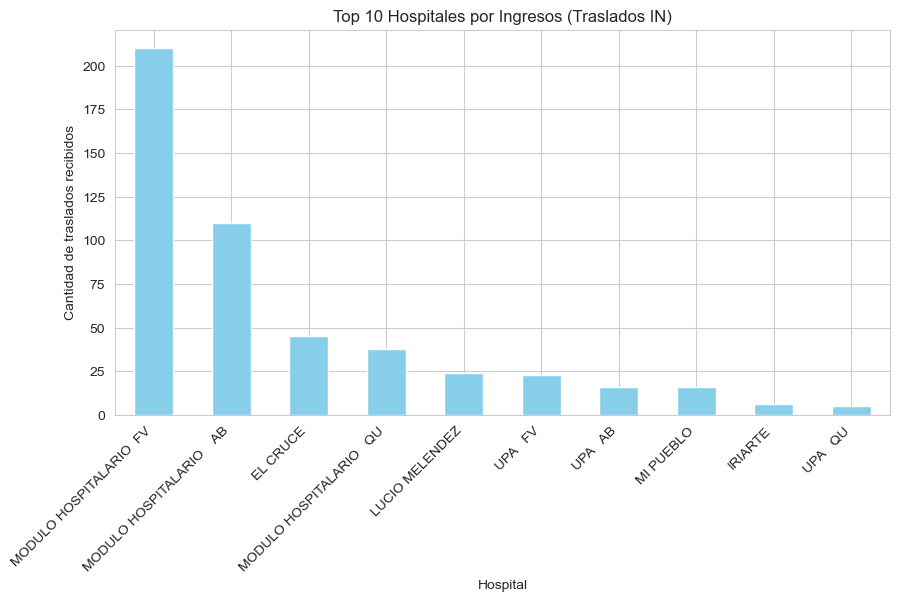

In [32]:
# Traslados OUT (Origen)
traslados_out = bases.traslados_por_hospital(traslados, col_hospital="Nombre Hospital", graficar=False)

# Traslados IN (Destino)
traslados_in = bases.traslados_por_hospital(traslados, col_hospital="Hospital siguiente", graficar=False)

tabla_hospitales = pd.DataFrame({
    "traslados_out": traslados_out,
    "traslados_in": traslados_in,
}).fillna(0)

print("Top 10 hospitales que derivan más pacientes:")
display(tabla_hospitales.sort_values(by="traslados_out", ascending=False).head(10))

print("\nTop 10 hospitales que reciben más pacientes:")
display(tabla_hospitales.sort_values(by="traslados_in", ascending=False).head(10))

# Graficamos los IN
tabla_hospitales["traslados_in"].sort_values(ascending=False).head(10).plot(kind="bar", color="skyblue", figsize=(10,5))
plt.title("Top 10 Hospitales por Ingresos (Traslados IN)")
plt.ylabel("Cantidad de traslados recibidos")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
# ESTO ES STRENGTH O FUERZA
# DEGREE: # de hospitales con los que me conecto

# fuerza/grado = numero promedio de traslados que recibo de un hospital con el que estoy conectado

### 3.2 Tiempo promedio que pasa una persona dentro del hospital

Nombre Hospital
IRIARTE                        11.374545
MÓDULO HOSPITALARIO 10 - QU    10.727273
MÓDULO HOSPITALARIO 11- FV      9.533923
OÑATIVIA                        7.953526
EL CRUCE                        7.558974
MÓDULO HOSPITALARIO  9 - AB     7.253731
LUCIO MELÉNDEZ                  6.539130
OLLER                           5.974638
EVITA PUEBLO                    5.499205
MI PUEBLO                       5.062500
Name: Duracion días, dtype: float64

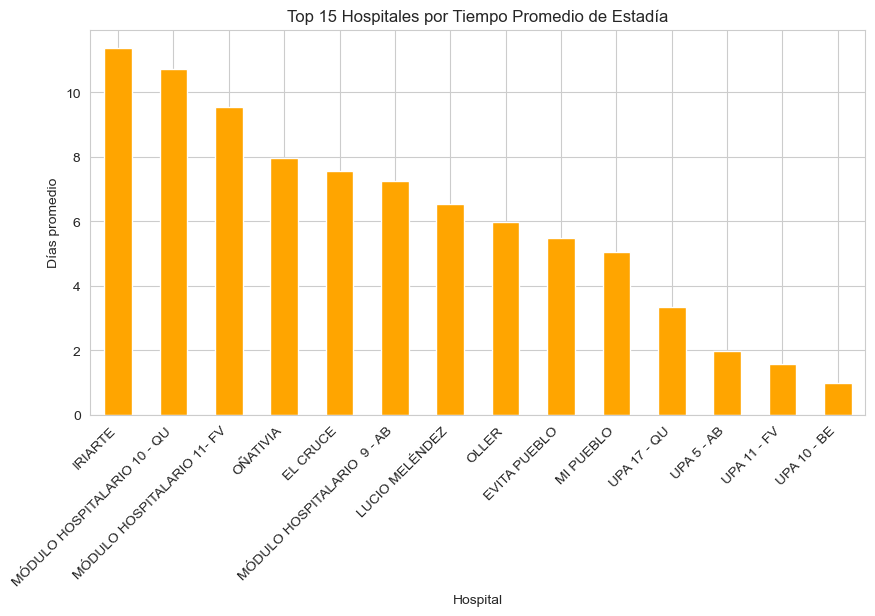

In [33]:
# Tiempo promedio por hospital
tiempo_prom_hosp = bases.tiempo_promedio_por_hospital(df_pacientes, col_hospital="Nombre Hospital", col_dias="Duracion días", quantile_outlier=0.95, graficar=False)

display(tiempo_prom_hosp.head(10))

tiempo_prom_hosp.head(15).plot(kind="bar", color="orange", figsize=(10,5))
plt.title("Top 15 Hospitales por Tiempo Promedio de Estadía")
plt.ylabel("Días promedio")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
# agregar los valores a las barras

### 3.3 Cantidad de muertos por hospital

Nombre Hospital
OÑATIVIA                       109
EVITA PUEBLO                   100
LUCIO MELÉNDEZ                  91
IRIARTE                         82
MI PUEBLO                       77
MÓDULO HOSPITALARIO 11- FV      66
EL CRUCE                        56
MÓDULO HOSPITALARIO  9 - AB     40
MÓDULO HOSPITALARIO 10 - QU     27
UPA 5 - AB                      25
dtype: int64

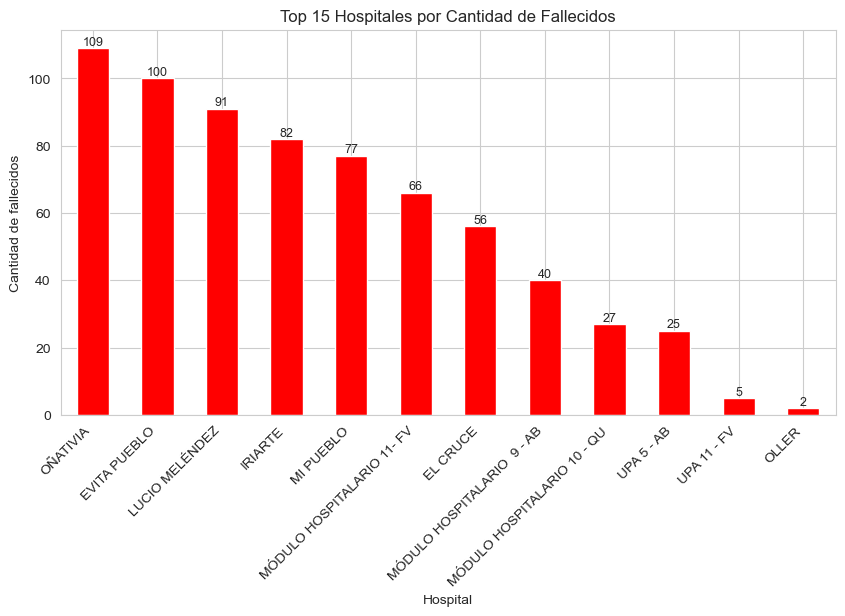

In [34]:
muertes_hosp = bases.muertes_por_hospital(
    df_pacientes,
    col_hospital="Nombre Hospital",
    col_muerte="murio",
    graficar=False
)

display(muertes_hosp.head(10))

ax = muertes_hosp.head(15).plot(kind="bar", color="red", figsize=(10,5))

# agregar numerito arriba de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Top 15 Hospitales por Cantidad de Fallecidos")
plt.ylabel("Cantidad de fallecidos")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

In [43]:
## entrar a la red o volver a casa o muerte
## version: optimista


# ver que rol tienen estos indicadores en la caminata

## 4. Análisis Combinado

### 4.1 Cantidad de personas con distintos niveles de riesgo social y estados (crítico, intermedio general)

Estado al ingreso,ocupadas_covid,ocupadas_otros,sospechosos,Total
Nivel riesgo social,,,,
no,923,718,1476,3117
si,778,201,1269,2248
Total,1701,919,2745,5365


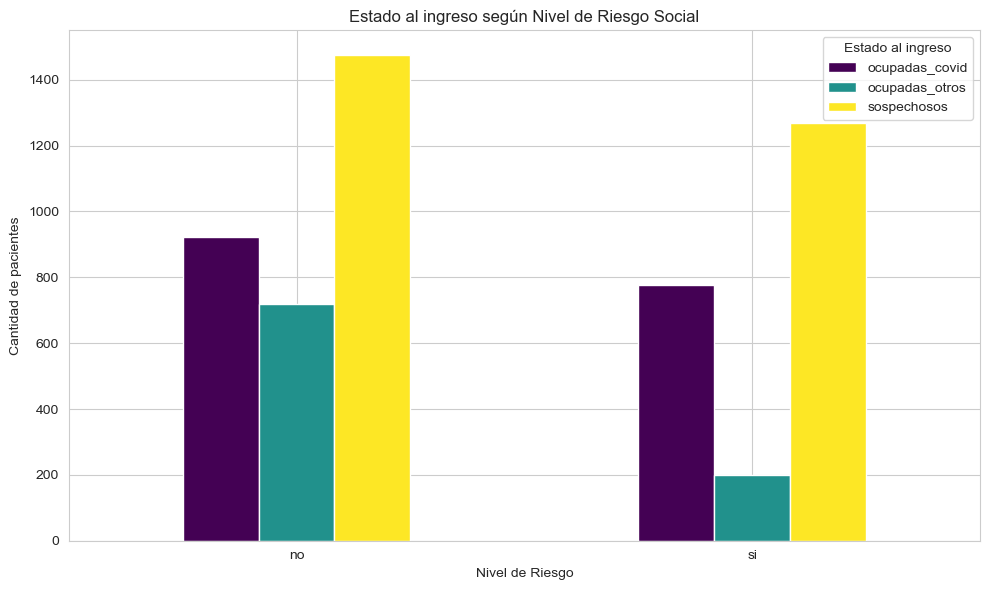

In [35]:
# Tabla cruzada de Nivel de riesgo social y Estado al ingreso
# Tabla cruzada de Nivel de riesgo social y Estado al ingreso
if "Nivel riesgo social" in df_pacientes.columns and "Estado al ingreso" in df_pacientes.columns:

    tabla_riesgo_estado = pd.crosstab(
        df_pacientes["Nivel riesgo social"],
        df_pacientes["Estado al ingreso"],
        margins=True,
        margins_name="Total"
    )

    display(tabla_riesgo_estado)

    tabla_sin_totales = pd.crosstab(
        df_pacientes["Nivel riesgo social"],
        df_pacientes["Estado al ingreso"]
    )

    tabla_sin_totales.plot(
        kind="bar",
        stacked=False,
        figsize=(10,6),
        colormap="viridis"
    )

    plt.title("Estado al ingreso según Nivel de Riesgo Social")
    plt.ylabel("Cantidad de pacientes")
    plt.xlabel("Nivel de Riesgo")
    plt.xticks(rotation=0)
    plt.legend(title="Estado al ingreso")
    plt.tight_layout()
    plt.show()

else:
    print("Las columnas necesarias para este análisis no están disponibles.")
    print("Columnas disponibles:", df_pacientes.columns.tolist())

### 4.2 Relacionar Secciones (Tiempos vs. Riesgo Social / Estado)

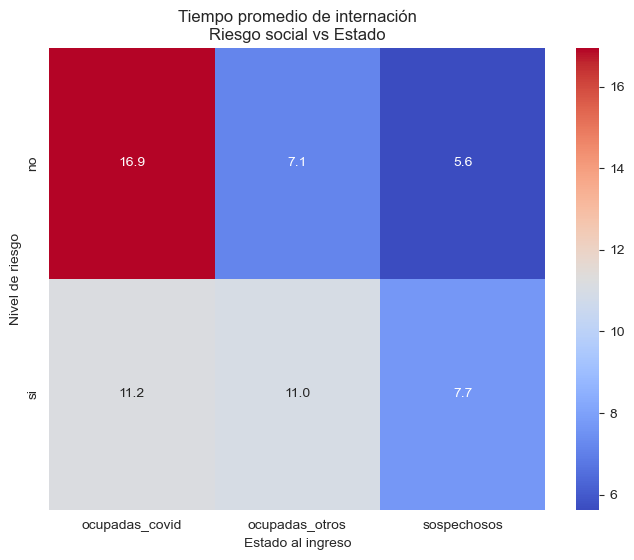

Estado al ingreso,ocupadas_covid,ocupadas_otros,sospechosos
Nivel riesgo social,,,
no,16.946667,7.149533,5.625596
si,11.161631,10.988235,7.682746


In [36]:
bases.relacion_tiempo_riesgo_estado(df_pacientes)